<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Ejercicio1_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1: Regularización por Dropout
Nombre: Catalina Núñez

* Ejercicio 1
* Ejercicio 2



## 1. Importaciones y carga de datos

In [ ]:
# Importamos librerías necesarias

from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# Cargamos datos de entrenamiento y prueba de CIFAR10

(imgs_train,labs_train), (imgs_test,labs_test) = keras.datasets.cifar10.load_data()
print(imgs_train.shape)
print(imgs_test.shape)

nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camión']

(50000, 32, 32, 3)
(10000, 32, 32, 3)


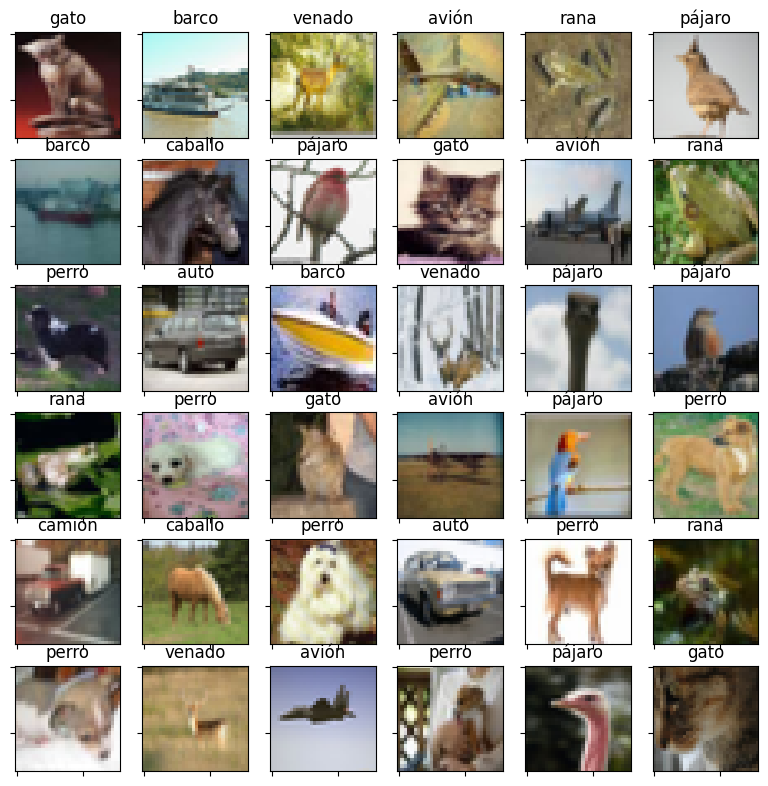

In [ ]:
# Mostramos una grilla de ejemplos (al azar) del conjunto de test

h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(imgs_test))
    axs[i,j].set_title(nombres[labs_test[ex][0]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(imgs_test[ex])

In [ ]:
# cantidad de ejemplos (train/test), neuronas de entrada y neuronas de salida

M_train = X_train.shape[0]
M_test = X_test.shape[0]

N = X_train.shape[1]
C = Y_train.shape[1]

print(N,C,M_train,M_test)

3072 10 50000 10000


In [ ]:
# Setamos los seed para números random

np.random.seed(30)
tf.random.set_seed(30)


# Creamos nuestra red feed-forward (tiene 4 capas escondidas!)

h1 = 512
h2 = 256

red = keras.Sequential()
red.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

red.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,773,066 (6.76 MB)

 Trainable params: 1,773,066 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = red.fit(X_train, Y_train,
        epochs=150,
        batch_size=128,
        validation_data=(X_test,Y_test)
       )

Epoch 1/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2860 - loss: 1.9903 - val_accuracy: 0.3425 - val_loss: 1.8497
Epoch 2/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3591 - loss: 1.8098 - val_accuracy: 0.3806 - val_loss: 1.7621
Epoch 3/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3861 - loss: 1.7385 - val_accuracy: 0.4012 - val_loss: 1.6998
Epoch 4/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4071 - loss: 1.6859 - val_accuracy: 0.4166 - val_loss: 1.6530
Epoch 5/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4218 - loss: 1.6437 - val_accuracy: 0.4293 - val_loss: 1.6172
Epoch 6/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4347 - loss: 1.6082 - val_accuracy: 0.4399 - val_loss: 1.5854
Epoch 7/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4447 - loss: 1.5781 - val_accuracy: 0.4492 - val_loss: 1.5615
Epoch 8/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4540 - loss: 1.5508 - val_accu

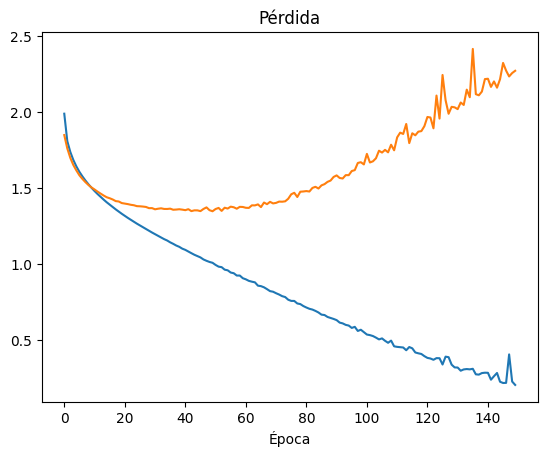

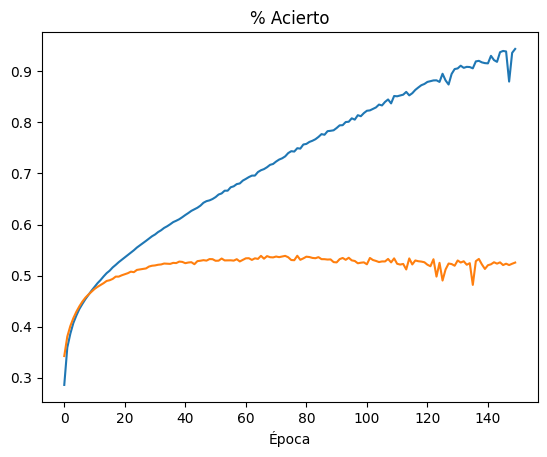

In [ ]:
# Mostramos la pérdida y el acierto por cada época


#Este grafico (el primero) muestra en el grafico azul la funcion de costo (si decrementa es pq está aprendiendo) de los datos de train
#muestra en el grafico naranjo la funcion de costo (si decrementa es pq está aprendiendo) de los datos de test

#Costo de train decrementa, costo de test aumenta, esto es indicio de overfitting (memorización de test)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Comienzo de los 2 ejercicios**



---



## Ejercicio  1: Regularización por Dropout

Para agregar  Dropout en keras simplemente usamos la capa `keras.layers.Dropout(p)` donde `p` es la probabilidad de dropout (de apagar una  neurona). Para agregar una de  estas capas simplemente usamos `add` como cualquier otra.
```
Note que agregamos una capa de dropout entre la primera y la segunda capa.

Crea una nueva red `red_reg` haciendo lo siguiente:
- Agrega una capa de dropout entre cada una de  las capas escondidas de la red usando un dropout entre 0.2 y 0.5.
- Entrena la red por 150 épocas para que veas cómo cambia el aprendizaje.
- Guarda la historia del  entrenamiento en una variable `hist_reg` para luego poder graficarla junto a la historia del entrenamiento anterior.
- Imprime el historial de la pérdida y el acierto para este nuevo entrenamiento.
- Imprime el acierto del entrenamiento con y sin regularización en un mismo  gráfico.

¿Obtienes mejores resultados en cuanto al acierto?

In [ ]:
### a)  Crea y entrena la  red

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

# a) Creamos la red con Dropout
red_reg = keras.Sequential()
red_reg.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))
red_reg.add(keras.layers.Dense(h2, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))
red_reg.add(keras.layers.Dense(h2, activation='relu'))
red_reg.add(keras.layers.Dropout(0.3))
red_reg.add(keras.layers.Dense(C, activation='softmax'))

red_reg.summary()

red_reg.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

hist_reg = red_reg.fit(X_train, Y_train,
        epochs=150,
        batch_size=128,
        validation_data=(X_test, Y_test)
       )

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,773,066 (6.76 MB)

 Trainable params: 1,773,066 (6.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2369 - loss: 2.0600 - val_accuracy: 0.3145 - val_loss: 1.9216
Epoch 2/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2899 - loss: 1.9241 - val_accuracy: 0.3419 - val_loss: 1.8249
Epoch 3/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3100 - loss: 1.8798 - val_accuracy: 0.3601 - val_loss: 1.7891
Epoch 4/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3254 - loss: 1.8457 - val_accuracy: 0.3778 - val_loss: 1.7571
Epoch 5/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3362 - loss: 1.8240 - val_accuracy: 0.3819 - val_loss: 1.7498
Epoch 6/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3407 - loss: 1.8031 - val_accuracy: 0.3949 - val_loss: 1.7243
Epoch 7/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3481 - loss: 1.7859 - val_accuracy: 0.3901 - val_loss: 1.7274
Epoch 8/150
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3484 - loss: 1.7854 - val_acc

### b) Imprime el historial de entrenamiento

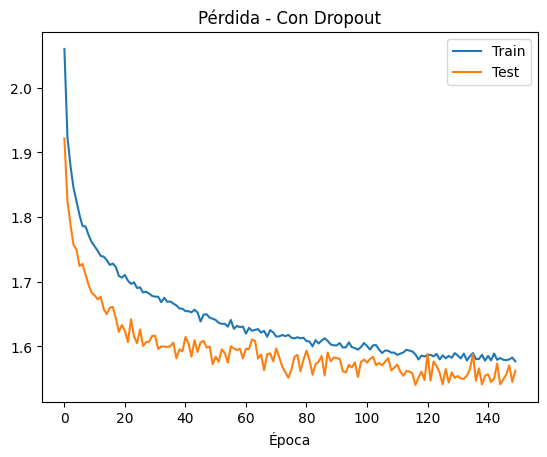

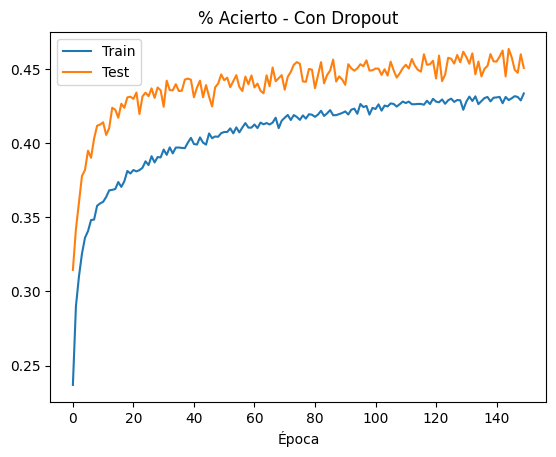

In [ ]:
plt.plot(hist_reg.history['loss'])
plt.plot(hist_reg.history['val_loss'])
plt.title('Pérdida - Con Dropout')
plt.xlabel('Época')
plt.legend(['Train', 'Test'])
plt.show()

plt.plot(hist_reg.history['accuracy'])
plt.plot(hist_reg.history['val_accuracy'])
plt.title('% Acierto - Con Dropout')
plt.xlabel('Época')
plt.legend(['Train', 'Test'])
plt.show()


### c) Compara el historial con y sin regularización

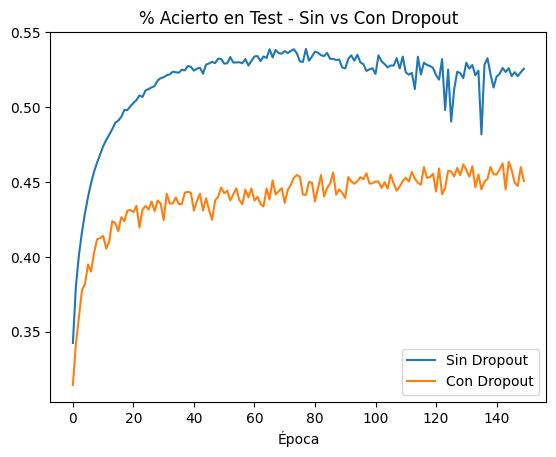

Mejor acierto SIN Dropout: 53.88%
Mejor acierto CON Dropout: 46.35%


In [ ]:
# con y sin regularización

plt.plot(hist.history['val_accuracy'], label='Sin Dropout')
plt.plot(hist_reg.history['val_accuracy'], label='Con Dropout')
plt.title('% Acierto en Test - Sin vs Con Dropout')
plt.xlabel('Época')
plt.legend()
plt.show()

print(f"Mejor acierto SIN Dropout: {max(hist.history['val_accuracy'])*100:.2f}%")
print(f"Mejor acierto CON Dropout: {max(hist_reg.history['val_accuracy'])*100:.2f}%")


### d) Muestra una grilla con ejemplos y las predicciones de la red

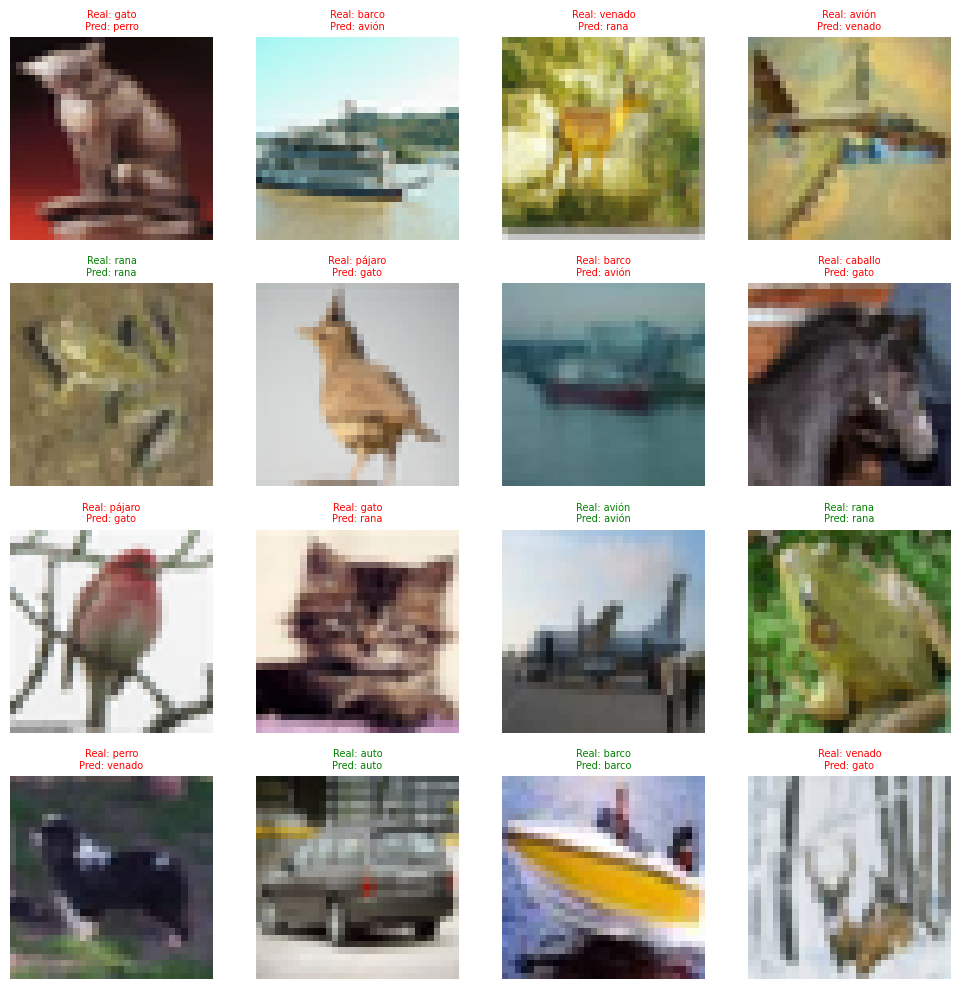

In [ ]:
# d) Grilla con predicciones
h_grid, w_grid = 4, 4
fig, axs = plt.subplots(h_grid, w_grid, figsize=(2.5*w_grid, 2.5*h_grid))

for i in range(h_grid):
    for j in range(w_grid):
        ex = np.random.randint(len(imgs_test))
        pred = red_reg.predict(X_test[ex].reshape(1,-1), verbose=0)
        clase_pred = np.argmax(pred)
        clase_real = labs_test[ex][0]
        color = 'green' if clase_pred == clase_real else 'red'
        axs[i,j].imshow(imgs_test[ex])
        axs[i,j].set_title(
            f'Real: {nombres[clase_real]}\nPred: {nombres[clase_pred]}',
            fontsize=7, color=color
        )
        axs[i,j].axis('off')

plt.tight_layout()
plt.show()

## Ejercicio 2: Mejora el acierto en el test set

Usa lo que  has aprendido de regularización para intentar mejorar el acierto en el test set. Puede intentar con un dropout más agresivo, cambiando el tamaño del batch (más pequeño puede mejorar pero demora la ejecución!), aumentando la capacidad de tu red, etc.

Otro cambio  que puedes hacer es cambiar la tasa de aprendizaje.  Para eso puedes usar las funcionalidades en `keras.optimizers`.  Por ejemplo, para usar SGD con una tasa de aprendizaje de `0.001` puedes usar un código como este:


Incluso puedes hacer búsqueda de hiperparámetros para encontrar la mejor red respecto del acierto en el test set. Para esto puedes programar un loop en donde vas probando la red para distintos hiperparámetros. Si lo haces ordenado y estás dispuesto a esperar, puedes encontrar redes que mejoren sustancialmente las métricas.

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,777,162 (6.78 MB)

 Trainable params: 1,775,114 (6.77 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2835 - loss: 2.1153 - val_accuracy: 0.3630 - val_loss: 1.7829
Epoch 2/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3462 - loss: 1.8499 - val_accuracy: 0.4026 - val_loss: 1.6704
Epoch 3/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3724 - loss: 1.7602 - val_accuracy: 0.4156 - val_loss: 1.6244
Epoch 4/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3927 - loss: 1.7078 - val_accuracy: 0.4447 - val_loss: 1.5663
Epoch 5/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3999 - loss: 1.6738 - val_accuracy: 0.4335 - val_loss: 1.6017
Epoch 6/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4022 - loss: 1.6608 - val_accuracy: 0.4501 - val_loss: 1.5382
Epoch 7/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4117 - loss: 1.6478 - val_accuracy: 0.4626 - val_loss: 1.5373
Epoch 8/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4199 - loss: 1.6245 - val_acc

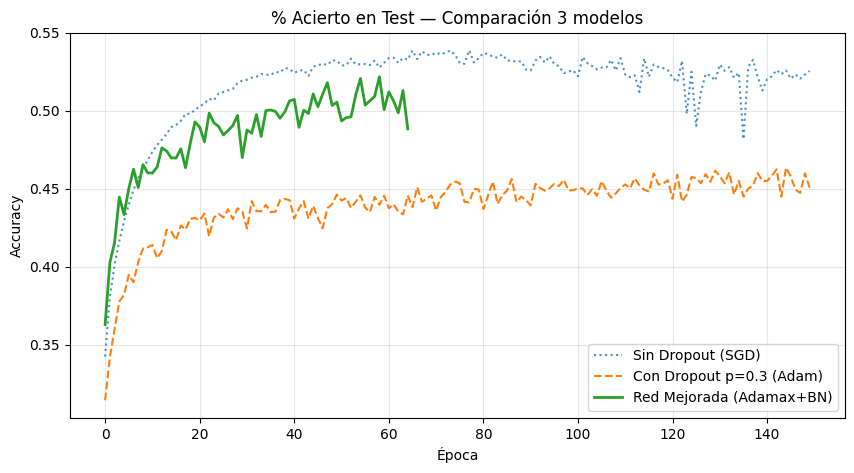

Acierto SIN Dropout      : 53.88%
Acierto CON Dropout 0.3  : 46.35%
Acierto Red Mejorada     : 52.18%


In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

# Usamos Adamax con learning rate más bajo para mayor estabilidad
adamax_opt = keras.optimizers.Adamax(learning_rate=0.001)

# y BatchNormalization para estabilizar el entrenamiento
red_mejor = keras.Sequential()
red_mejor.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())
red_mejor.add(keras.layers.Dropout(0.4))
red_mejor.add(keras.layers.Dense(h2, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())
red_mejor.add(keras.layers.Dropout(0.4))
red_mejor.add(keras.layers.Dense(h2, activation='relu'))
red_mejor.add(keras.layers.BatchNormalization())
red_mejor.add(keras.layers.Dropout(0.2))
red_mejor.add(keras.layers.Dense(C, activation='softmax'))

red_mejor.summary()

red_mejor.compile(
    loss='categorical_crossentropy',
    optimizer=adamax_opt,
    metrics=['accuracy']
)

# Early stopping para detener cuando val_loss deje de mejorar
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

hist_mejor = red_mejor.fit(X_train, Y_train,
        epochs=150,
        batch_size=64,
        validation_data=(X_test, Y_test),
        callbacks=[early_stop]
       )

# Comparación de los 3 modelos
plt.figure(figsize=(10, 5))
plt.plot(hist.history['val_accuracy'],        label='Sin Dropout (SGD)',         linestyle=':',  alpha=0.8)
plt.plot(hist_reg.history['val_accuracy'],    label='Con Dropout p=0.3 (Adam)',  linestyle='--')
plt.plot(hist_mejor.history['val_accuracy'],  label='Red Mejorada (Adamax+BN)',  linewidth=2)
plt.title('% Acierto en Test — Comparación 3 modelos')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Acierto SIN Dropout      : {max(hist.history['val_accuracy'])*100:.2f}%")
print(f"Acierto CON Dropout 0.3  : {max(hist_reg.history['val_accuracy'])*100:.2f}%")
print(f"Acierto Red Mejorada     : {max(hist_mejor.history['val_accuracy'])*100:.2f}%")

Con Dropout se obtienen mejores resultados. Se puede ver en el gráfico que sin regularización la red empieza a memorizar los datos de entrenamiento (overfitting), mientras que con Dropout las curvas de train y test quedan más parejas. Básicamente el Dropout "estresa" a la red apagando neuronas al azar, lo que la obliga a aprender de forma más general y no solo memorizar.